<a href="https://colab.research.google.com/github/AneDesiree/knn-breast-cancer-classification/blob/main/breast_cancer_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Breast cancer classification using k-Nearest Neighbors**\
**Author: Aiane Desirée dos Santos Bastos**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets
df = pd.concat([X, y], axis=1)

**1. Caracterizando os dados quanto a tipo e escala:**

In [ ]:
tipo_e_escala = {'Tipo': ['Numérico',   'Numérico',   'Numérico',   'Numérico',   'Numérico',   'Numérico',   'Numérico',   'Numérico',
'Numérico',   'Categórico'  ],'Escala': ['Ordinal', 'Ordinal', 'Ordinal', 'Ordinal', 'Ordinal', 'Ordinal', 'Ordinal', 'Ordinal',
'Ordinal',   'Nominal']}
caracterizacao_dados_df = pd.DataFrame(tipo_e_escala)
caracterizacao_dados_df.index = ['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size',
'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class']
caracterizacao_dados_df

,Tipo,Escala
Clump_thickness,Numérico,Ordinal
Uniformity_of_cell_size,Numérico,Ordinal
Uniformity_of_cell_shape,Numérico,Ordinal
Marginal_adhesion,Numérico,Ordinal
Single_epithelial_cell_size,Numérico,Ordinal
Bare_nuclei,Numérico,Ordinal
Bland_chromatin,Numérico,Ordinal
Normal_nucleoli,Numérico,Ordinal
Mitoses,Numérico,Ordinal
Class,Categórico,Nominal


O conjunto de dados é multivariado com 9 atributos preditivos e 1 atributo alvo.

**2. Verificando se os dados estão balanceados:**

In [ ]:
counts = y.value_counts()
percent = y.value_counts(normalize=True) * 100
res = pd.DataFrame({'Quantidade': counts, 'Porcentagem (%)': percent})
display(res)

,Quantidade,Porcentagem (%)
Class,,
2,458,65.522175
4,241,34.477825


**3. Caracterizando estatisticamente os dados:**

In [ ]:
freq = df.count()
moda = df.mode()
def extrair_moda(serie):
    serie = serie.dropna()
    if len(serie) == 1:
        return serie.iloc[0]
    elif len(serie) > 1:
        return ', '.join(map(str, serie))
    else:
        return 'nan'
moda = moda.apply(extrair_moda, axis=0)
mediana = X.median()
media = X.mean()
desvio = X.std()
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
curt = X.kurtosis()
skew = X.skew()
df_stats = pd.DataFrame({'Frequência': freq, 'Moda': moda,'Mediana': mediana,'Média': media,'Desvio padrão': desvio,'1° Quartil': Q1, '3° Quartil': Q3,
'Curtose': curt, 'Obliquidade': skew,})
df_stats = df_stats.reindex(df.columns)
display(df_stats)

,Frequência,Moda,Mediana,Média,Desvio padrão,1° Quartil,3° Quartil,Curtose,Obliquidade
Clump_thickness,699,1.0,4.0,4.417740,2.815741,2.0,6.0,-0.623715,0.592859
Uniformity_of_cell_size,699,1.0,1.0,3.134478,3.051459,1.0,5.0,0.098803,1.233137
Uniformity_of_cell_shape,699,1.0,1.0,3.207439,2.971913,1.0,5.0,0.007011,1.161859
Marginal_adhesion,699,1.0,1.0,2.806867,2.855379,1.0,4.0,0.987947,1.524468
Single_epithelial_cell_size,699,2.0,2.0,3.216023,2.214300,2.0,4.0,2.169066,1.712172
Bare_nuclei,683,1.0,1.0,3.544656,3.643857,1.0,6.0,-0.798844,0.990016
Bland_chromatin,699,2.0,3.0,3.437768,2.438364,2.0,5.0,0.184621,1.099969
Normal_nucleoli,699,1.0,1.0,2.866953,3.053634,1.0,4.0,0.474269,1.422261
Mitoses,699,1.0,1.0,1.589413,1.715078,1.0,1.0,12.657878,3.560658
Class,699,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**4. Pré-processamento dos dados:**

In [ ]:
# Substituindo valores NaN pela mediana da coluna
df['Bare_nuclei'] = df['Bare_nuclei'].fillna(df['Bare_nuclei'].median())

In [ ]:
#Verificando valores inconsistentes para os atributos
display(df.apply(lambda x: x.unique()))

,0
Clump_thickness,"[5, 3, 6, 4, 8, 1, 2, 7, 10, 9]"
Uniformity_of_cell_size,"[1, 4, 8, 10, 2, 3, 7, 5, 6, 9]"
Uniformity_of_cell_shape,"[1, 4, 8, 10, 2, 3, 5, 6, 7, 9]"
Marginal_adhesion,"[1, 5, 3, 8, 10, 4, 6, 2, 9, 7]"
Single_epithelial_cell_size,"[2, 7, 3, 1, 6, 4, 5, 8, 10, 9]"
Bare_nuclei,"[1.0, 10.0, 2.0, 4.0, 3.0, 9.0, 7.0, 5.0, 8.0,..."
Bland_chromatin,"[3, 9, 1, 2, 4, 5, 7, 8, 6, 10]"
Normal_nucleoli,"[1, 2, 7, 4, 5, 3, 10, 6, 9, 8]"
Mitoses,"[1, 5, 4, 2, 3, 7, 10, 8, 6]"
Class,"[2, 4]"


Não há presença de dados inconsistentes no dataset.

In [ ]:
# Verificando redundância de objetos
linhas_duplicadas = df.duplicated()
print(linhas_duplicadas.sum())

242


In [ ]:
# Excluindo as linhas duplicadas, mantendo a primeira ocorrência
df_clean = df.drop_duplicates()
print(df_clean.count())

Clump_thickness                457
Uniformity_of_cell_size        457
Uniformity_of_cell_shape       457
Marginal_adhesion              457
Single_epithelial_cell_size    457
Bare_nuclei                    457
Bland_chromatin                457
Normal_nucleoli                457
Mitoses                        457
Class                          457
dtype: int64


In [ ]:
X_clean = df_clean.drop(columns = ['Class'])
y_clean = df_clean['Class']

In [ ]:
counts = y_clean.value_counts()
percent = y_clean.value_counts(normalize=True) * 100
res = pd.DataFrame({'Quantidade': counts, 'Porcentagem (%)': percent})
display(res)

,Quantidade,Porcentagem (%)
Class,,
4,238,52.078775
2,219,47.921225


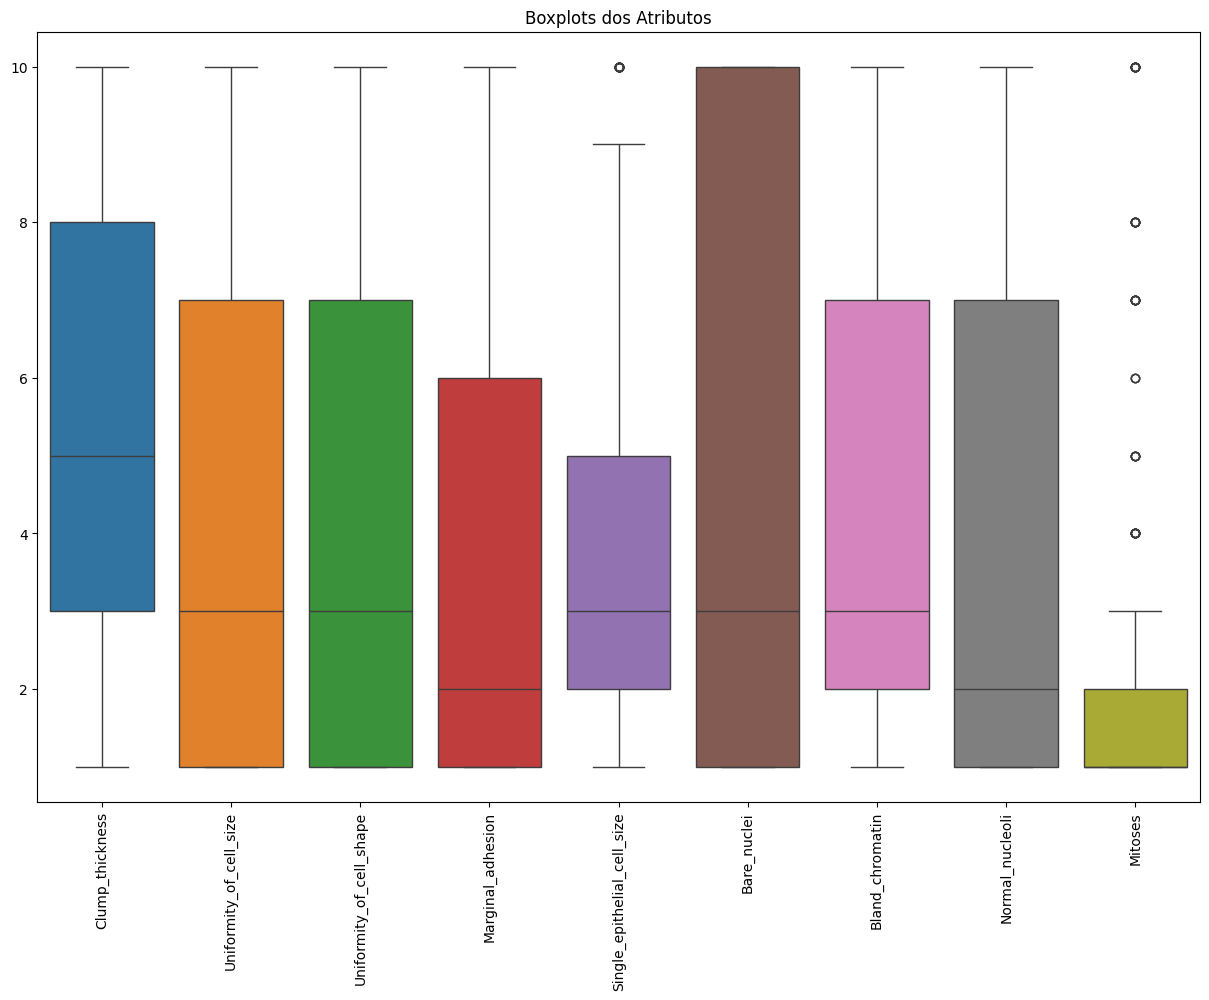

In [ ]:
plt.figure(figsize=(15, 10))
sns.boxplot(X_clean)
plt.xticks(rotation=90)
plt.title('Boxplots dos Atributos')
plt.show()

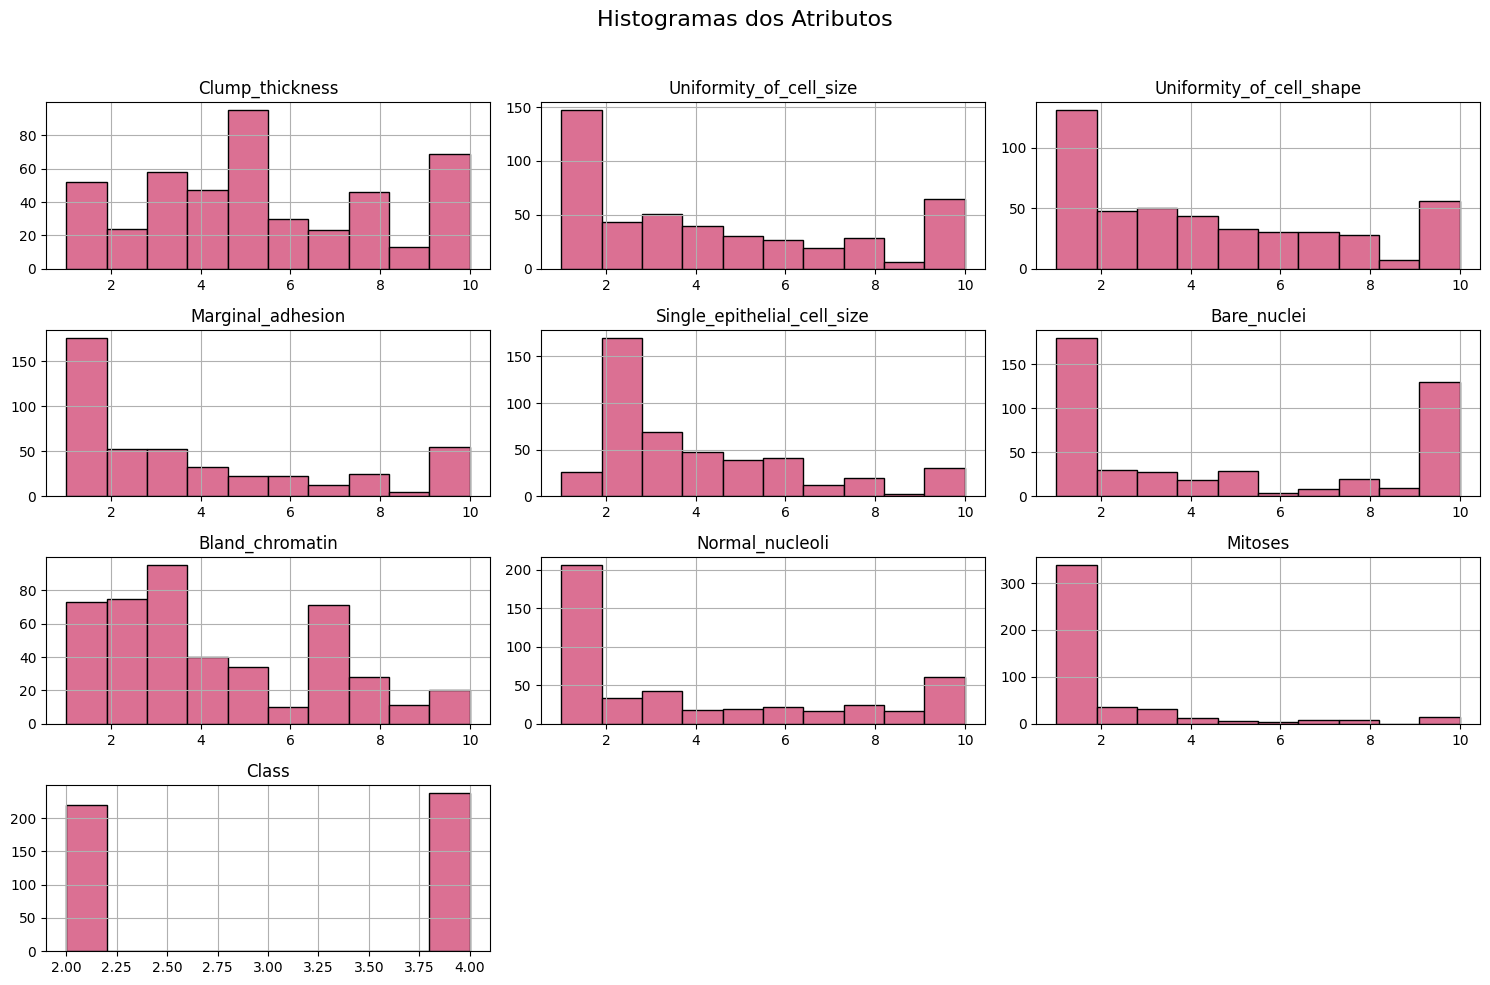

In [ ]:
df_clean.hist(figsize=(15, 10), bins=10, color='palevioletred', edgecolor='black')
plt.suptitle('Histogramas dos Atributos', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

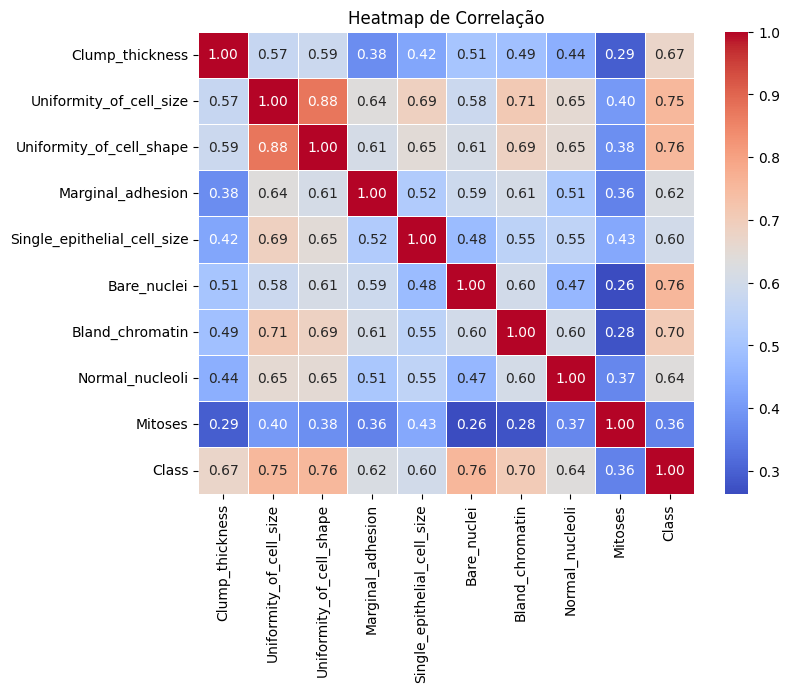

In [ ]:
# Correlação entre os atributos preditivos
correlation_matrix = df_clean.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Heatmap de Correlação')
plt.show()

**4.1. Preparando os dados para aplicar o algoritmo k-NN:**

In [ ]:
# Separando os atributos preditivos do atributo alvo com o dataset já limpo
X = X_clean
y = y_clean

In [ ]:
# Dividindo os dados entre treinamento e teste com proporção de 30% para o conjunto de teste e 70% para o de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Escalonando dos dados
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**5. PCA:**

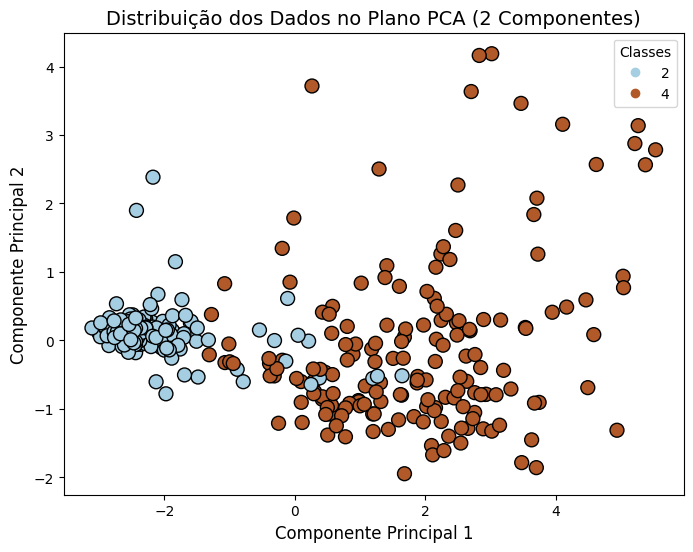

In [ ]:
# Aplicando PCA para reduzir para 2 componentes principais
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Plotando a distribuição dos dados no plano PCA
plt.figure(figsize=(8, 6))

# Plotando os pontos de treino
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.Paired, edgecolor='k', s=100, label="Treinamento")

# Adicionando a legenda
plt.legend(*scatter.legend_elements(), title="Classes")

# Títulos e labels
plt.title('Distribuição dos Dados no Plano PCA (2 Componentes)', fontsize=14)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)

plt.show()

O gráfico PCA mostra a distribuição dos dados projetados em duas dimensões, com a separação das classes 2 e 4 no plano das componentes principais. Embora haja uma boa separação entre as classes, há uma sobreposição na região central, indicando que as classes não são perfeitamente separáveis nesse espaço. Isso sugere que um modelo como o KNN pode ter dificuldades em classificar corretamente as amostras nas áreas de sobreposição.

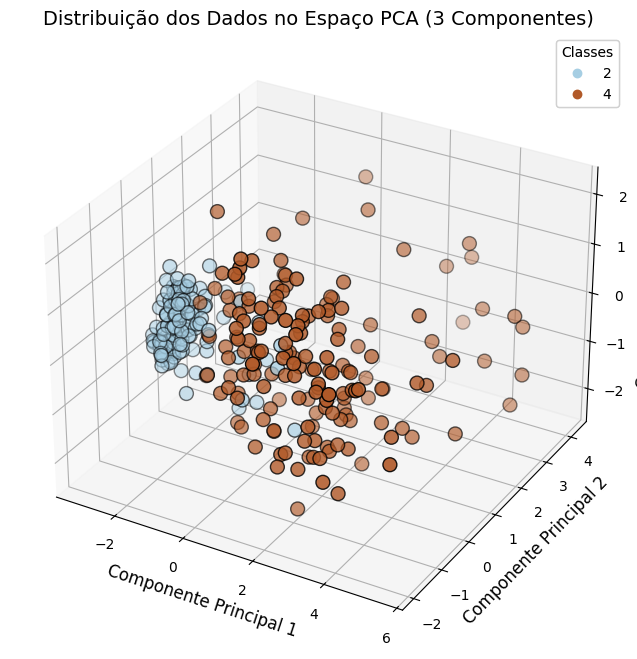

In [ ]:
pca = PCA(n_components=3)
X_train_pca3d = pca.fit_transform(X_train)
X_test_pca3d = pca.transform(X_test)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_train_pca3d[:, 0], X_train_pca3d[:, 1], X_train_pca3d[:, 2], c=y_train, cmap=plt.cm.Paired, edgecolor='k', s=100)
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)
ax.set_title('Distribuição dos Dados no Espaço PCA (3 Componentes)', fontsize=14)
ax.set_xlabel('Componente Principal 1', fontsize=12)
ax.set_ylabel('Componente Principal 2', fontsize=12)
ax.set_zlabel('Componente Principal 3', fontsize=12)

plt.show()

Observa-se que a classe 2 está bem agrupada, o que sugere uma maior similaridade entre suas características principais. A classe 4 está mais dispersa, indicando maior variabilidade interna. Apesar da sobreposição em algumas áreas, a separação geral entre as classes sugere que as três componentes principais capturaram bem as diferenças relevantes entre elas.

**6. k-NN:**

**6.1 - Validação cruzada**

k = 1: Acurácia Média = 0.9280
k = 2: Acurácia Média = 0.9154
k = 3: Acurácia Média = 0.9530
k = 4: Acurácia Média = 0.9405
k = 5: Acurácia Média = 0.9468
k = 6: Acurácia Média = 0.9467
k = 7: Acurácia Média = 0.9499
k = 8: Acurácia Média = 0.9404
k = 9: Acurácia Média = 0.9467
k = 10: Acurácia Média = 0.9435
k = 11: Acurácia Média = 0.9404
k = 12: Acurácia Média = 0.9404
k = 13: Acurácia Média = 0.9435
k = 14: Acurácia Média = 0.9435
k = 15: Acurácia Média = 0.9467
k = 16: Acurácia Média = 0.9404
k = 17: Acurácia Média = 0.9435
k = 18: Acurácia Média = 0.9435
k = 19: Acurácia Média = 0.9435
k = 20: Acurácia Média = 0.9467
Melhor valor de k é 3 com Acurácia = 0.9530


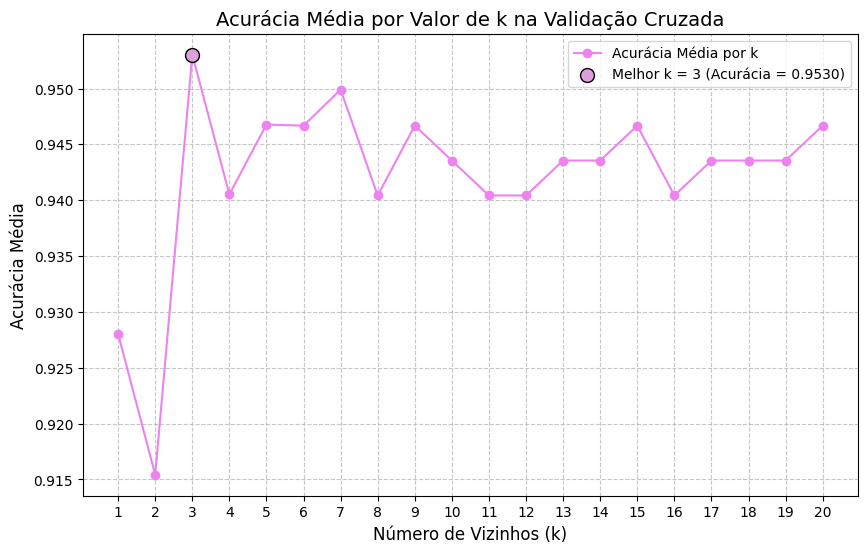

In [ ]:
k_val = range(1, 21)
cv_scores = []

for k in k_val:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f'k = {k}: Acurácia Média = {scores.mean():.4f}')

melhor_k = k_val[cv_scores.index(max(cv_scores))]
maior_acuracia = max(cv_scores)
print(f"Melhor valor de k é {melhor_k} com Acurácia = {maior_acuracia:.4f}")

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(k_val, cv_scores, marker='o', linestyle='-', color='violet', label='Acurácia Média por k')
plt.scatter(melhor_k, maior_acuracia, color='plum', edgecolor='black', s=100, zorder=5, label=f'Melhor k = {melhor_k} (Acurácia = {maior_acuracia:.4f})')
plt.title('Acurácia Média por Valor de k na Validação Cruzada', fontsize=14)
plt.xlabel('Número de Vizinhos (k)', fontsize=12)
plt.ylabel('Acurácia Média', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_val)
plt.show()

In [ ]:
# Treinamento com o melhor K
best_knn = KNeighborsClassifier(n_neighbors=melhor_k)
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

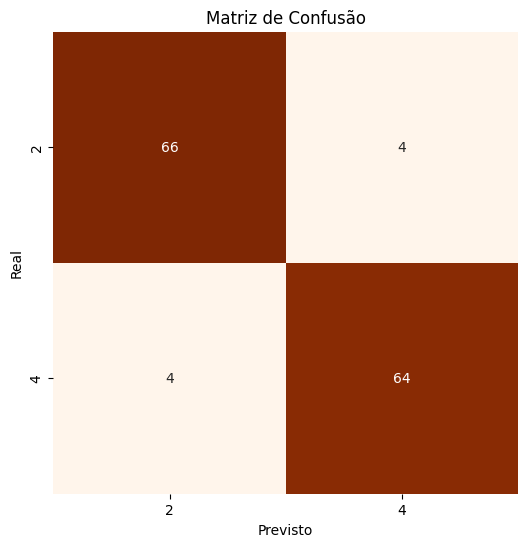

In [ ]:
# Matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', xticklabels=[2, 4], yticklabels=[2, 4], cbar=False)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

In [ ]:
# Métricas de desempenho
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=4)
recall = recall_score(y_test, y_pred, pos_label=4)
f1 = f1_score(y_test, y_pred, pos_label=4)
print("\nDesempenho do Melhor Modelo:")
print(f"Acurácia: {accuracy:.2f}")
print(f"Precisão: {precision:.2f}")
print(f"Revocação: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Extraindo as métricas da matriz de confusão
VN, FP, FN, VP = conf_matrix.ravel()

# Medidas de desempenho considerando 4 como classe positiva
TFN = FN / (FN + VP)
TFP = FP / (FP + VN)
esp = 1 - TFP
err_total = (FP + FN) / (VP + VN + FP + FN)  # Erro total
print(f"Taxa de Falsos Negativos (TFN): {TFN:.2f}")
print(f"Taxa de Falsos Positivos (TFP): {TFP:.2f}")
print(f"Especificidade: {esp:.2f}")
print(f"Taxa de erro total: {err_total:.2f}")


Desempenho do Melhor Modelo:
Acurácia: 0.94
Precisão: 0.94
Revocação: 0.94
F1-Score: 0.94
Taxa de Falsos Negativos (TFN): 0.06
Taxa de Falsos Positivos (TFP): 0.06
Especificidade: 0.94
Taxa de erro total: 0.06


In [ ]:
# Relatório de classificação
print("\033[1m\nRelatório de classificação:\n\033[0m", classification_report(y_test, y_pred))


Relatório de classificação:
               precision    recall  f1-score   support

           2       0.94      0.94      0.94        70
           4       0.94      0.94      0.94        68

    accuracy                           0.94       138
   macro avg       0.94      0.94      0.94       138
weighted avg       0.94      0.94      0.94       138



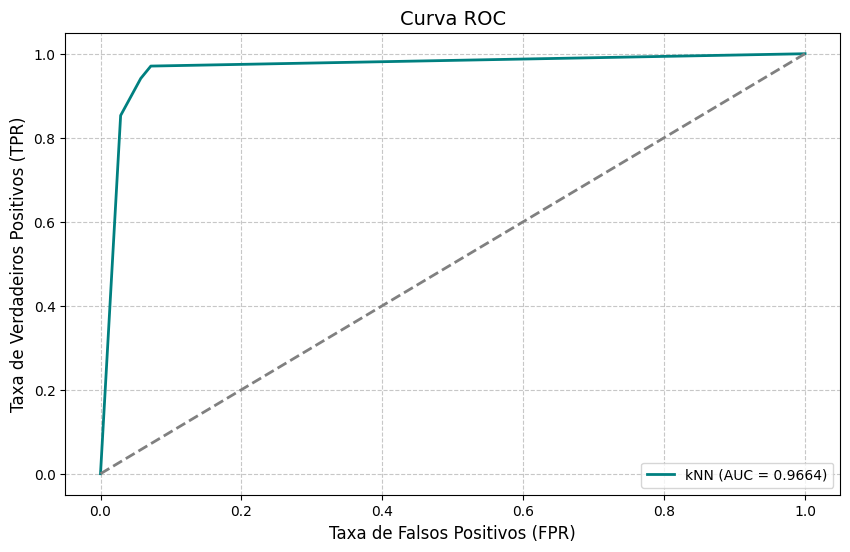

In [ ]:
y_probs = best_knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=4)
roc_auc = roc_auc_score(y_test, y_probs)

# Curva ROC
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='teal', lw=2, label=f'kNN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.title('Curva ROC', fontsize=14)
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

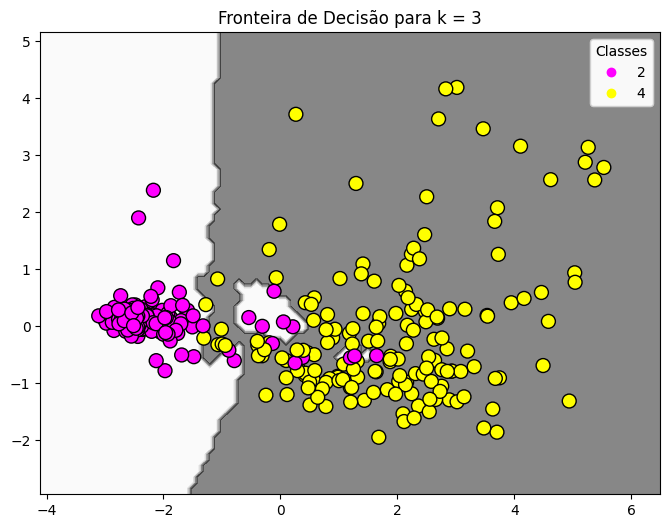

In [ ]:
# Reduzindo para 2 dimensões com PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Treinando novamente o modelo
best_knn.fit(X_train_2d, y_train)

def plot_decision_boundary_with_legend(X, y, model, ax=None, title="Fronteira de Decisão"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    if ax is None:
        fig, ax = plt.subplots()
    ax.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.Greys)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.spring, edgecolor='k', s=100)
    legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
    ax.add_artist(legend1)

    ax.set_title(title)
    return ax

fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundary_with_legend(X_train_2d, y_train, best_knn, ax=ax, title=f"Fronteira de Decisão para k = {melhor_k}")
plt.show()


No gráfico de fronteira de decisão para k = 3, as áreas cinza e branca representam as regiões de decisão atribuídas pelo modelo kNN para as duas classes (amarela e rosa). Como k = 3 considera apenas os três vizinhos mais próximos, a fronteira é irregular e apresenta maior sensibilidade a variações locais nos dados.
O “buraco branco” no meio da área cinza representa uma região da fronteira de decisão onde o modelo kNN classificou essa área como pertencente à classe da região branca (ou seja, a classe 2), apesar de estar rodeada por pontos da classe cinza (4).